# 06. Transfer learning

to learn/take parameters/ weights from similar problem space -> patterns get tuned to specific problem.

* Preytained model = foundation models

###Why transfer learning?
* Can leverage existing neural netwok architecture **proven to work** on problems similar to our own.
* Leverage a working network architecture which has **already learned patterns** on similar data to our own (great results with less data)

How? for example:

* Learn patterns in a wide variety of images (using imageNet) ->

* Pretrained EfficientNet architecture (already works well on computer vision tasks) ->

* Extract/tune patterns/weights to suit our own problem ->

* Model performs better than from scratch.

transfer learning -> world class work with less resources and less data.
                  -> reduce overfitting.
                  -> utilize time.

###Where to find pretrained models?



* PyTorch domains libraries (torchvision, torchtext, torchaudio, torchrec)
Source: https://pytorch.org/vision/stable/models.html

* Torch Image Models (timm library)
Source: https://github.com/rwightman/pytorch-image-models

* HuggingFace Hub
Source: https://huggingface.co/models

* Paperswithcode SOTA
Source: https://paperswithcode.com/sota

🔍 General & Multi-domain Sources
TensorFlow Hub
A repository of trained machine learning models ready for fine-tuning or inference.
🔗 https://tfhub.dev

Keras Applications
Includes popular CNN architectures pretrained on ImageNet.
🔗 https://keras.io/api/applications/

ONNX Model Zoo
Pretrained models in the ONNX format for interoperability across frameworks.
🔗 https://github.com/onnx/models

Model Zoo for Intel OpenVINO
Optimized models for edge inference.
🔗 https://docs.openvino.ai/latest/omz_models_group.html

🧠 Vision Models
MMClassification / MMDetection / MMPretrain (OpenMMLab)
Strong repositories for pretrained vision models (classification, detection, segmentation).
🔗 https://github.com/open-mmlab

Detectron2 Model Zoo (by Facebook AI)
Pretrained models for object detection and segmentation.
🔗 https://github.com/facebookresearch/detectron2/blob/main/MODEL_ZOO.md

💬 Natural Language Processing (NLP)
AllenNLP Pretrained Models
Pretrained NLP models and components for research.
🔗 https://allennlp.org/models

SpaCy Pretrained Pipelines
Ready-to-use NLP pipelines for named entity recognition, tagging, etc.
🔗 https://spacy.io/models

🔊 Audio & Speech
SpeechBrain Model Zoo
Models for speech recognition, speaker identification, and more.
🔗 https://huggingface.co/speechbrain

ESPnet Pretrained Models
End-to-end speech processing models.
🔗 https://github.com/espnet/espnet_model_zoo

### importing libraries

In [1]:
import torch
import torchvision

print(torch.__version__)
print(torchvision.__version__)

2.6.0+cu124
0.21.0+cu124


we will import the code we have written in previous sections.

In [2]:
# Import libraries
import torch
import matplotlib.pyplot as plt
import torchvision

from torch import nn
from torchvision import transforms

import sys
import os

try:
  from torchinfo import summary
except:
  !pip install -q torchinfo
  from torchinfo import summary

try:
  from going_modular import data_setup, engine
except:
  print("[INFO] Couldn't find going modular scripts...downloading them from GitHub.")
  !git clone https://github.com/esraalmaeeni/pytorch-zero-to-mastery-MyPractice # we can also keep data in same file and clone it
  !mv pytorch-zero-to-mastery-MyPractice/going_modular .
  !rm -rf pytorch-zero-to-mastery-MyPractice
  if '.' not in sys.path:
        sys.path.append(os.getcwd())
  from going_modular import data_setup, engine

In [3]:
# Setup device agnostic code
device = "cuda" if torch.cuda.is_available() else "cpu"
device

'cuda'

## 1. Get data

In [4]:
import os
import zipfile
from pathlib import Path

import requests

# Setup data path
data_path = Path("data/")
image_path = data_path / "pizza_steak_sushi"

# If the image folder doesn't exist, download and prepare it
if image_path.is_dir():
  print(f"{image_path} directory exists, skipping re-download.")
else:
  print(f"Did not find {image_path}, downloading it")
  image_path.mkdir(parents=True, exist_ok=True)

  # Download data
  with open(data_path/ "pizza_steak_sushi.zip", "wb") as f:
    request = requests.get("https://github.com/mrdbourke/pytorch-deep-learning/raw/refs/heads/main/data/pizza_steak_sushi.zip")
    print("Downloading pizza, steak, sushi data... ")
    f.write(request.content)

  #unzip data
  with zipfile.ZipFile(data_path / "pizza_steak_sushi.zip", "r") as zip_ref:
    print("Unzipping pizza, steak, sushi data...")
    zip_ref.extractall(image_path)

  # Remove zip file
  os.remove(data_path / "pizza_steak_sushi.zip")

data/pizza_steak_sushi directory exists, skipping re-download.


In [5]:
# Setup directory paths
train_dir = image_path / "train"
test_dir = image_path / "test"

## 2. Create Datasets and DataLoaders

Now we've got some data, want to turn it into PyTorch DataLoaders.

using `data_setup.create_dataloaders()` function.

but, how to transforms it? `torchvision`
1. manually create transforms.
2. automatically create transforms, defined by the model we use.

IMP: when using pretrained model, the data must be transformed in the same way the data the model was trained on.

### 2.1 Creating a transform for `torchvision.models` (manual creation)

`torchvision.models` contains pretrained models (models ready for transfer learning).

>all pretrained models expect input images to be normalized in the same way. i.e. mini batches of 3 channel (3xHxW), H & W in range of at least 224. The image have to be loaded in to a range of [0, 1] , normalized using mean=[mean=[0.485, 0.456, 0.406],
                                            std=[0.229, 0.224, 0.225]

In [6]:
from torchvision import transforms
normalize = transforms.Normalize(mean=[0.485, 0.456, 0.406],
                                 std=[0.229, 0.224, 0.225])
manual_transforms = transforms.Compose([
                                        transforms.Resize((224,224)),
                                        transforms.ToTensor(),
                                        normalize
                                        ])

In [7]:
from going_modular import data_setup
train_dataloader, test_dataloader, class_names = data_setup.create_dataloaders(train_dir=train_dir,
                                                                               test_dir=test_dir,
                                                                               transform=manual_transforms,
                                                                               batch_size=32)

### 2.2 Creating a transform for `torchvision.models` (auto creation)

As of `torchvision` > 0.12 versions there is support for automatic data transform creation based on the foundation model used.

In [8]:
import torchvision
print(torchvision.__version__)

0.21.0+cu124


In [9]:
# Get a set of pre-trained model weights
weights = torchvision.models.EfficientNet_B0_Weights.DEFAULT # DEFAULT = best available weights

In [10]:
# Get the transforms used to create our pretrained weights
auto_transform = weights.transforms()
auto_transform

ImageClassification(
    crop_size=[224]
    resize_size=[256]
    mean=[0.485, 0.456, 0.406]
    std=[0.229, 0.224, 0.225]
    interpolation=InterpolationMode.BICUBIC
)

In [11]:
# Create DataLoaders using automatic transforms
train_dataloader, test_dataloader, class_names = data_setup.create_dataloaders(train_dir=train_dir,
                                                                               test_dir=test_dir,
                                                                               transform=auto_transform,
                                                                               batch_size=32)

## 3. Getting a pretrained model

There are various places to get a pretrained model, such as:
1. PyTorch domain libraries.
2. Libraries like timm (torch image models).
3. HuggingFace Hub.
4. Paperswithcode (for models acrss diff spaces/domain).

### 3.1 Which pre-trained model to pick?

*Experiment, experiment, experiment!*

The whole idea of transfer learning to take an alreade well-performing model from a problem space similar to your problem then costumize it to your problem.

Consider 3 things:
1. Speed How fast does it run? ex. in self-driving cars it must be in real-time.
2. Size - how big is the model? (the hardware must be good to carry it)
2. Size - how big does it go on your chosen problem (e.g. how well it classify food images as we creating FoodVision Mini)

Where does the model live?
Is it on device (like self-driving car as we want it to be fast) or a server?

the less parameters the faster it will run. we want highest accuracy and the least parameters.

>Best performance + least No. of params = fast models.
https://docs.pytorch.org/vision/stable/models.html

Which model should we choose?

we will choose EffNetB0 as best option in terms of performance x speed.

The more data you have, the more compute you have. https://www.cs.utexas.edu/~eunsol/courses/data/bitter_lesson.pdf


### 3.2 Setting up a pretrained model using `torchvision.models`
https://docs.pytorch.org/vision/stable/models/generated/torchvision.models.efficientnet_b0.html#torchvision.models.EfficientNet_B0_Weights

In [12]:
# OLD method of creating a pretrained model (prior to torchvision 0.13)
model = torchvision.models.efficientnet_b0(pretrained=True)

# NEW method of creating a pretrained model (torchvision 0.13+)
weights = torchvision.models.EfficientNet_B0_Weights.DEFAULT
model = torchvision.models.efficientnet_b0(weights=weights).to(device)


/usr/local/lib/python3.11/dist-packages/torchvision/models/_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
/usr/local/lib/python3.11/dist-packages/torchvision/models/_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=EfficientNet_B0_Weights.IMAGENET1K_V1`. You can also use `weights=EfficientNet_B0_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)


In [13]:
model.features

Sequential(
  (0): Conv2dNormActivation(
    (0): Conv2d(3, 32, kernel_size=(3, 3), stride=(2, 2), padding=(1, 1), bias=False)
    (1): BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (2): SiLU(inplace=True)
  )
  (1): Sequential(
    (0): MBConv(
      (block): Sequential(
        (0): Conv2dNormActivation(
          (0): Conv2d(32, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), groups=32, bias=False)
          (1): BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
          (2): SiLU(inplace=True)
        )
        (1): SqueezeExcitation(
          (avgpool): AdaptiveAvgPool2d(output_size=1)
          (fc1): Conv2d(32, 8, kernel_size=(1, 1), stride=(1, 1))
          (fc2): Conv2d(8, 32, kernel_size=(1, 1), stride=(1, 1))
          (activation): SiLU(inplace=True)
          (scale_activation): Sigmoid()
        )
        (2): Conv2dNormActivation(
          (0): Conv2d(32, 16, kernel_size=(1, 1), stride=(1, 1), 

In [14]:
model.avgpool

AdaptiveAvgPool2d(output_size=1)

In [15]:
model.classifier

Sequential(
  (0): Dropout(p=0.2, inplace=True)
  (1): Linear(in_features=1280, out_features=1000, bias=True)
)

**Kinds of transfer Learning:**
* *original model*: large dataset -> working architecture -> output



* *feature extraction transfer learning model:* different dataset -> frozen original model layers -> diff output (useful for small amount of custom dataset, original architecture frozen, only top 1-3 updated to adjuct the output for our problem)


* *Fine-tuning:* might change dataset -> frozen architecture of 1st & 2nd layers -> unfrozen remaining architecture (trained on new data) -> diff output
(slowly unfreeze layer by layer from top, need large custom data)

### 3.3 Getting a summary of our model using `torchinfo.summary()`

In [16]:
# Print with torchinfo
from torchinfo import summary

summary(model=model,
        input_size=(1,3,224,224),
        col_names=["input_size", "output_size", "num_params", "trainable"],
        col_width=20,
        row_settings= ["var_names"])

Layer (type (var_name))                                      Input Shape          Output Shape         Param #              Trainable
EfficientNet (EfficientNet)                                  [1, 3, 224, 224]     [1, 1000]            --                   True
├─Sequential (features)                                      [1, 3, 224, 224]     [1, 1280, 7, 7]      --                   True
│    └─Conv2dNormActivation (0)                              [1, 3, 224, 224]     [1, 32, 112, 112]    --                   True
│    │    └─Conv2d (0)                                       [1, 3, 224, 224]     [1, 32, 112, 112]    864                  True
│    │    └─BatchNorm2d (1)                                  [1, 32, 112, 112]    [1, 32, 112, 112]    64                   True
│    │    └─SiLU (2)                                         [1, 32, 112, 112]    [1, 32, 112, 112]    --                   --
│    └─Sequential (1)                                        [1, 32, 112, 112]    [1, 16, 112,

> frozen means we turn the *Trainable=True* layers to *Trainable=False* except the 1-3 top layers and output.


### 3.4 Freezing the base model and changing the output layer to suit our needs

with a feature extractor model, typically you will "freeze" the base layers of pretrained/foundation model and update the output layers to suit our problem.   

In [17]:
# Freeze all of the base layers in EffNetB0
for param in model.features.parameters():
  #print(param)
  param.requires_grad = False

In [18]:
# Update the classifier head of our problem
#for param in model.classifier.parameters():
  #print(param)
from torch import nn

torch.manual_seed(42)

model.classifier = nn.Sequential(
    nn.Dropout(p=0.2, inplace=True),
    nn.Linear(in_features=1280,
              out_features=len(class_names))
).to(device)

In [19]:
summary(model=model,
        input_size=(1,3,224,224),
        col_names=["input_size", "output_size", "num_params", "trainable"],
        col_width=20,
        row_settings= ["var_names"])

Layer (type (var_name))                                      Input Shape          Output Shape         Param #              Trainable
EfficientNet (EfficientNet)                                  [1, 3, 224, 224]     [1, 3]               --                   Partial
├─Sequential (features)                                      [1, 3, 224, 224]     [1, 1280, 7, 7]      --                   False
│    └─Conv2dNormActivation (0)                              [1, 3, 224, 224]     [1, 32, 112, 112]    --                   False
│    │    └─Conv2d (0)                                       [1, 3, 224, 224]     [1, 32, 112, 112]    (864)                False
│    │    └─BatchNorm2d (1)                                  [1, 32, 112, 112]    [1, 32, 112, 112]    (64)                 False
│    │    └─SiLU (2)                                         [1, 32, 112, 112]    [1, 32, 112, 112]    --                   --
│    └─Sequential (1)                                        [1, 32, 112, 112]    [1, 1

## 4. Training the model

In [20]:
# Define loss and optimizer
loss_fn = nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(model.parameters(), lr=0.001)

In [21]:
# Import train function
from going_modular import engine

# Set the manual seed
torch.manual_seed(42)
torch.cuda.manual_seed(42)

# Start the time
from timeit import default_timer as Timer
start_time = Timer()

# Setup training and save the results
results = engine.train(model=model,
                       train_dataloader=train_dataloader,
                       test_dataloader=test_dataloader,
                       loss_fn=loss_fn,
                       optimizer=optimizer,
                       epochs=30,
                       device=device)

# End the timer
end_time = Timer()

# Print the training time
print(f"[INFO] The training time is: {end_time-start_time}")

  0%|          | 0/30 [00:00<?, ?it/s]

Epoch: 1 | train_loss: 1.0924 | train_acc: 0.3984 | test_loss: 0.8803 | test_acc: 0.6591
Epoch: 2 | train_loss: 0.8527 | train_acc: 0.8008 | test_loss: 0.7408 | test_acc: 0.8958
Epoch: 3 | train_loss: 0.8098 | train_acc: 0.6953 | test_loss: 0.6727 | test_acc: 0.8759
Epoch: 4 | train_loss: 0.7135 | train_acc: 0.7578 | test_loss: 0.6445 | test_acc: 0.8561
Epoch: 5 | train_loss: 0.6228 | train_acc: 0.7656 | test_loss: 0.5758 | test_acc: 0.8759
Epoch: 6 | train_loss: 0.6091 | train_acc: 0.7812 | test_loss: 0.5672 | test_acc: 0.8759
Epoch: 7 | train_loss: 0.5381 | train_acc: 0.8984 | test_loss: 0.5007 | test_acc: 0.8665
Epoch: 8 | train_loss: 0.5488 | train_acc: 0.7656 | test_loss: 0.4766 | test_acc: 0.8561
Epoch: 9 | train_loss: 0.5088 | train_acc: 0.7812 | test_loss: 0.4734 | test_acc: 0.8655
Epoch: 10 | train_loss: 0.4943 | train_acc: 0.7930 | test_loss: 0.4553 | test_acc: 0.8759
Epoch: 11 | train_loss: 0.4728 | train_acc: 0.8164 | test_loss: 0.4505 | test_acc: 0.8551
Epoch: 12 | train_l

In [22]:
results

{'train_loss': [1.0924270078539848,
  0.8526865467429161,
  0.8097705170512199,
  0.7135237082839012,
  0.6227593496441841,
  0.6091131195425987,
  0.5381340533494949,
  0.5488435067236423,
  0.5087519735097885,
  0.494312409311533,
  0.472771231085062,
  0.4179713614284992,
  0.4238676503300667,
  0.38298309966921806,
  0.42996959015727043,
  0.4228190314024687,
  0.35486550256609917,
  0.4371261913329363,
  0.3055709935724735,
  0.3023868724703789,
  0.2602905426174402,
  0.4529393631964922,
  0.29211863689124584,
  0.36310243606567383,
  0.2971318792551756,
  0.21643578633666039,
  0.38399433717131615,
  0.32542311400175095,
  0.2548822704702616,
  0.26931959204375744],
 'train_acc': [0.3984375,
  0.80078125,
  0.6953125,
  0.7578125,
  0.765625,
  0.78125,
  0.8984375,
  0.765625,
  0.78125,
  0.79296875,
  0.81640625,
  0.96875,
  0.94921875,
  0.9375,
  0.82421875,
  0.8125,
  0.953125,
  0.82421875,
  0.95703125,
  0.96875,
  0.984375,
  0.8203125,
  0.97265625,
  0.8359375,
  0

## 5. Evaluating our model and plotting loss curves

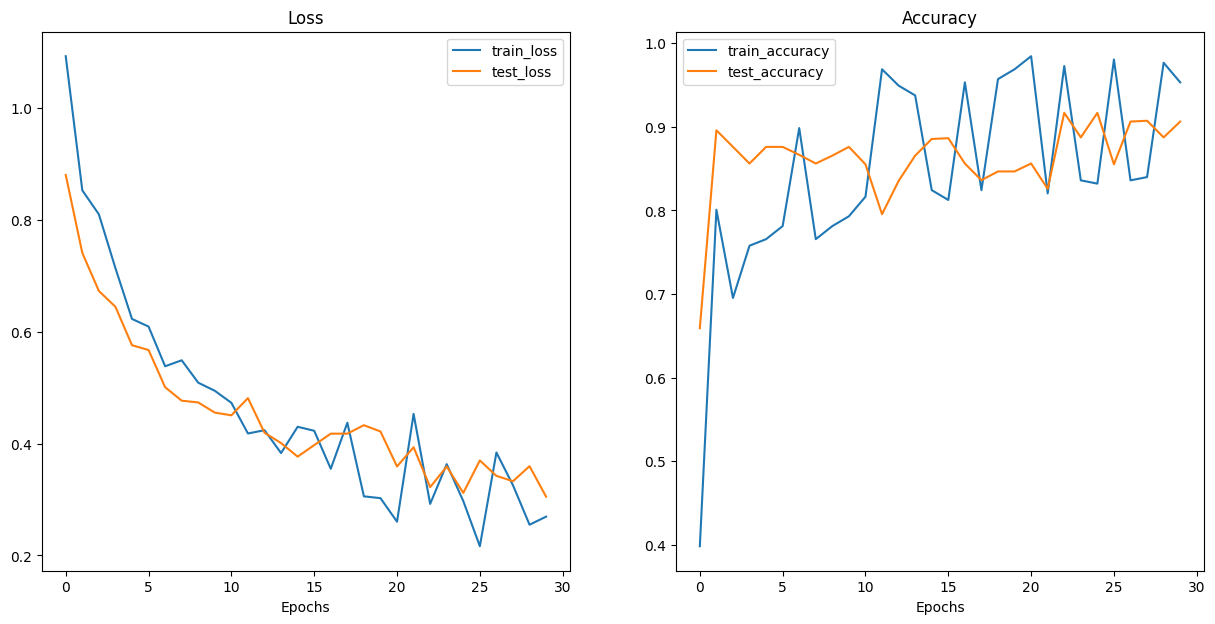

In [23]:
try:
  from helper_functions import plot_loss_curves
except:
  print(f"[INFO] Couldn't find helper_functions.py, downloading...")
  with open("helper_functions.py", "wb") as f:
    import requests
    request = requests.get("https://github.com/mrdbourke/pytorch-deep-learning/raw/refs/heads/main/helper_functions.py")
    f.write(request.content)
  from helper_functions import plot_loss_curves

# Plot loss curve of the model
plot_loss_curves(results)

## 6. Make predictions on images from the test set

during prediction to get similar prediction we need data to be:
same shape - same datatype - same device - same transform. To do this we build a function called `pred_and_plot`.
1. Take a trained model, a list of class names, a filepath to a target image, an image size, a transform and a target device.
2. Open the image with `PIL.Image.Open`
3. Create a transform if one doesn't exist.
4. Make sure the model is on the target device.
5. Turn the model to `model.eval()` mode to make sure it is ready for inference(This will turn off operations like `nn.Dropout()`.
6. Transform the target image and make sure its dimentionality is suitable.
7. Make pred on the image by passing it to the model.
8. Convert the model's output logit to probs using `torch.softmax()`
9. convert model preds probs to labels using `torch.argmax()`
10. plot the image with `matplotlib()` and the title to the prediction label and prob.

In [33]:
import matplotlib.pyplot as plt
from PIL import Image

from typing import List, Tuple
from torchvision import transforms

# 1. Define the function and args
def pred_and_plot_image(model: torch.nn.Module,
                        image_path: str,
                        class_names: List[str],
                        image_size: Tuple[int, int] = (224, 224),
                        transform: torchvision.transforms = None,
                        device: torch.device = device):
  # 2. Open the image with PIL
  img = Image.open(image_path)

  # 3. Create a transform if one does not exist
  if transform is not None:
    image_transform = transform
  else:
    image_transform = transforms.Compose([
                                        transforms.Resize(image_size),
                                        transforms.ToTensor(),
                                        transforms.Normalize(mean=[0.485, 0.456, 0.406],
                                                            std=[0.229, 0.224, 0.225])
    ])

  # 4. Make sure the model is on the target device
  model.to(device)

  # 5. Turn the model to eval mode to be ready for inference
  model.eval()
  with torch.inference_mode():
    # 6. Transform the image
    transformed_img = image_transform(img).unsqueeze(dim=0) # add batch dim

    # 7. pass the image through the model and make pred
    target_img_logit = model(transformed_img.to(device))

    # 8. Convert model pred logit to prob
    target_img_probs = torch.softmax(target_img_logit, dim=1)

    # 9. Convert model prob to label and prob
    target_img_label = torch.argmax(target_img_probs, dim=1).item()
    target_img_prob = target_img_probs[0][target_img_label].item()

  # 10. Plot the image and display the predicted label and prob
  plt.figure()
  plt.imshow(img)

  title = (f"Prediction: {class_names[target_img_label]} |"
           f"Probability: {target_img_prob * 100:.2f}%"
  )
  plt.title(title)

  plt.axis("off")

  plt.show()

In [34]:
class_names

['pizza', 'steak', 'sushi']

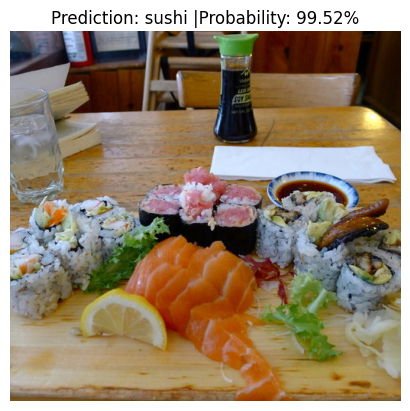

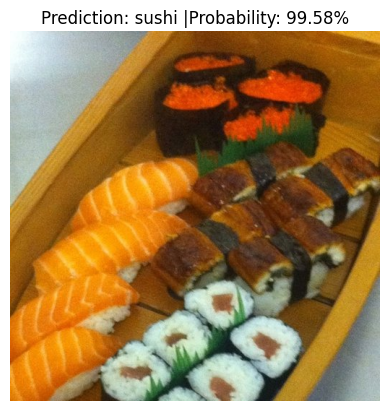

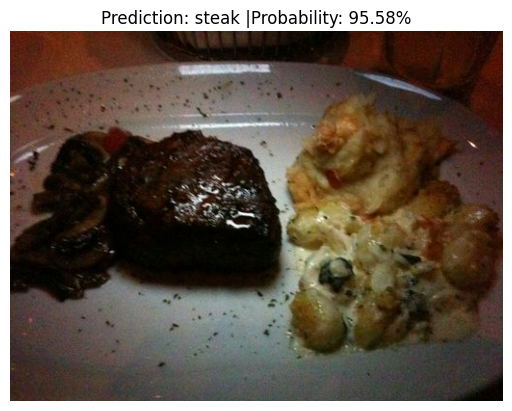

In [35]:
# Get a random list of image paths from the test set
import random

num_samples = 3
test_image_path_list = list(Path(test_dir).glob("*/*.jpg")) # WOAH! GLOB IS GREAT

random_test_samples = random.sample(population=test_image_path_list,
                                    k=num_samples)

for image_path in random_test_samples:
  pred_and_plot_image(model = model,
                      image_path= image_path,
                      class_names= class_names,
                      image_size=(224,224))

### 6.1  make a prediction on a custom image

In [36]:
# Download the image
import requests

# Setup custom image path
custom_image_path = data_path /"pizza.jpg"

# Download the image if it does not exist
if not custom_image_path.is_file():
  with open(custom_image_path, "wb") as f:
    # Download the image from GitHub
    request = requests.get("https://raw.githubusercontent.com/esraalmaeeni/pytorch-zero-to-mastery-MyPractice/main/images/pizza.jpg")
    print(f"Download {custom_image_path}...")
    f.write(request.content)
else:
  print(f"{custom_image_path} already exists, skipping downloading...")

data/pizza.jpg already exists, skipping downloading...


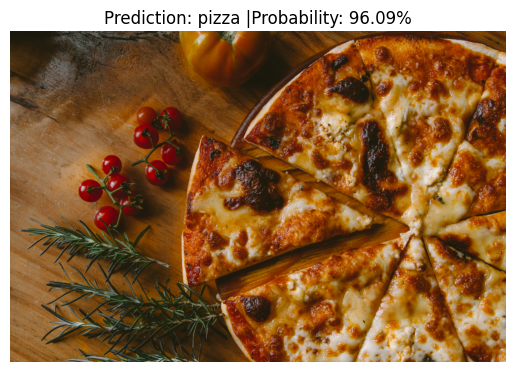

In [37]:
pred_and_plot_image(model = model,
                      image_path= custom_image_path,
                      class_names= class_names,
                      image_size=(224,224))

In [38]:
#DONE!